# IPL Bowling Analysis
Examining wicket-taking, economy, pressure bowling, and phase-wise performance
using ball-by-ball data (2008–2024).

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

delivery = pd.read_csv('Resources/deliveries.csv')
merged = pd.read_csv('Resources/merged_data.csv')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Top Wicket-Takers (All Time)

Taking wickets is one of the primary responsibilities of a bowler in T20 cricket. However, not every dismissal is credited to the bowler. Run outs and other non-bowling dismissals are excluded to accurately identify the IPL's leading wicket-takers.

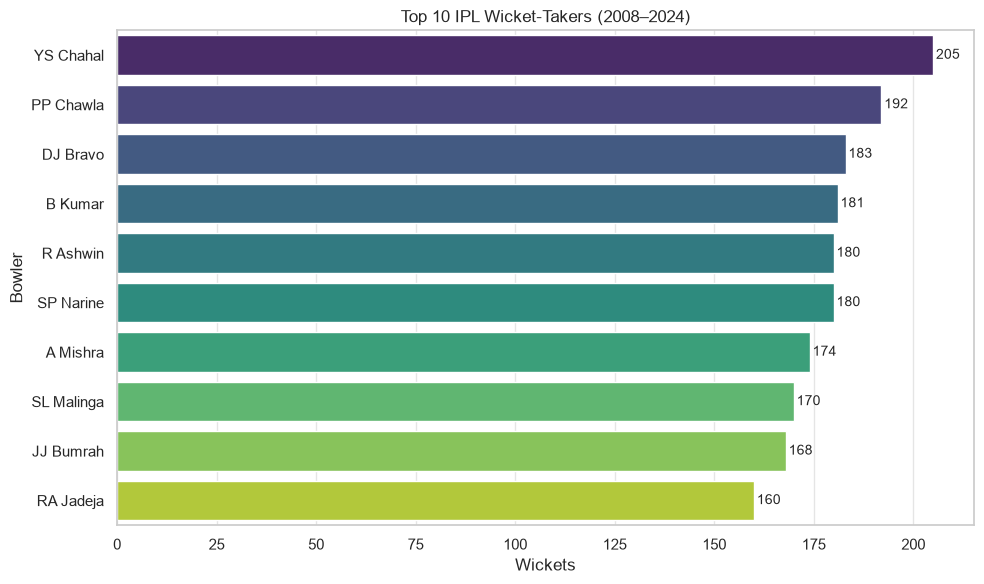

In [2]:
#Dismissals that are not credited to the bowler
non_bowler_dismissals = ['run out', 'retired hurt', 'obstructing the field', 'retired out']

#Filter wickets credited to the bowler
wickets_data = delivery[(delivery['is_wicket'] == 1) & (~delivery['dismissal_kind'].isin(non_bowler_dismissals))]
top_wickets = (wickets_data.groupby('bowler').size().sort_values(ascending=False).head(10))
top_wickets

#Visualisation
plt.figure(figsize=(10, 6))

ax = sns.barplot(x=top_wickets.values,y=top_wickets.index,palette="viridis", hue = top_wickets.index)
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=2)

plt.title("Top 10 IPL Wicket-Takers (2008–2024)")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.tight_layout()
plt.savefig("charts/top_wicket_takers.png", dpi=300)
plt.savefig("charts/top_wicket_takers.png")
plt.show()

### Observations

- **YS Chahal** leads the all-time wicket charts with **205 wickets**, followed by **PP Chawla** and **DJ Bravo**.
- The gap between the top few bowlers highlights the value of both longevity and sustained wicket-taking ability across multiple IPL seasons.
- Several bowlers in the top 10 have represented multiple franchises, reflecting long and successful IPL careers.

## 3. Best Economy Rates (Minimum 1000 Legal Deliveries)

Taking wickets is important, but preventing runs is equally valuable in T20 cricket. Economy rate measures the average number of runs conceded per over. To ensure a fair comparison, only bowlers who have delivered at least 500 legal balls are included.

Note: The dataset abbreviates player names. The entry "R Sharma" represents multiple players and was excluded from bowling analyses to avoid merging statistics from different bowlers.

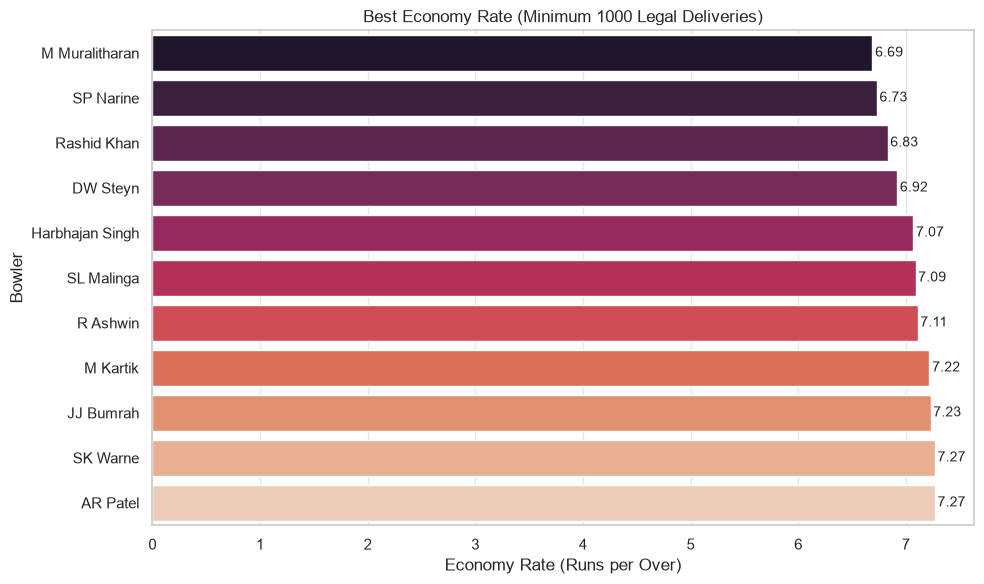

In [3]:
#Legal deliveries(excluding wides)
legal_deliveries = delivery[delivery['extras_type'] != 'wides']

# Legal balls bowled
balls_bowled = (legal_deliveries.groupby('bowler').size())

# Runs conceded by the bowler
delivery['bowler_runs'] = delivery['batsman_runs']

delivery.loc[delivery['extras_type'].isin(['wides', 'noballs']),'bowler_runs']\
    += delivery.loc[delivery['extras_type'].isin(['wides','noballs']),'extra_runs']

runs_conceded = delivery.groupby('bowler')['bowler_runs'].sum()

# Economy
economy = (runs_conceded / balls_bowled * 6).round(2)
MIN_BALLS = 1000
qualified_economy = (economy[balls_bowled >= MIN_BALLS].sort_values().head(11))
qualified_economy = qualified_economy.drop('R Sharma', errors='ignore') # Dropping the name R Sharma
#display(qualified_economy.to_frame(name="Economy"))

#Visualisation
plt.figure(figsize=(10,6))

ax = sns.barplot(x=qualified_economy.values,y=qualified_economy.index,palette="rocket", hue = qualified_economy.index)
for container in ax.containers:\
    ax.bar_label(container, fontsize=10, padding=2)

plt.title("Best Economy Rate (Minimum 1000 Legal Deliveries)")
plt.xlabel("Economy Rate (Runs per Over)")
plt.ylabel("Bowler")

plt.tight_layout()
plt.savefig("charts/economy_rate.png", dpi=300)
plt.show()

### Observations

- **M Murlitharan** has the best economy rate at **6.69 runs per over**, making him the most economical bowler among those with substantial IPL experience.
- Economy-focused bowlers are not always the highest wicket-takers, highlighting the trade-off between containing runs and attacking for wickets.
- Several spinners feature prominently, reflecting their effectiveness in restricting scoring during the middle overs.

## 4. Highest Dot Ball Percentage (Minimum 1000 Legal Deliveries)

Dot balls build pressure by preventing the batting side from scoring. While wicket-taking and economy rate measure different aspects of bowling, dot-ball percentage highlights bowlers who consistently restrict scoring opportunities.

To ensure a fair comparison, only bowlers with at least 1000 legal deliveries are included.

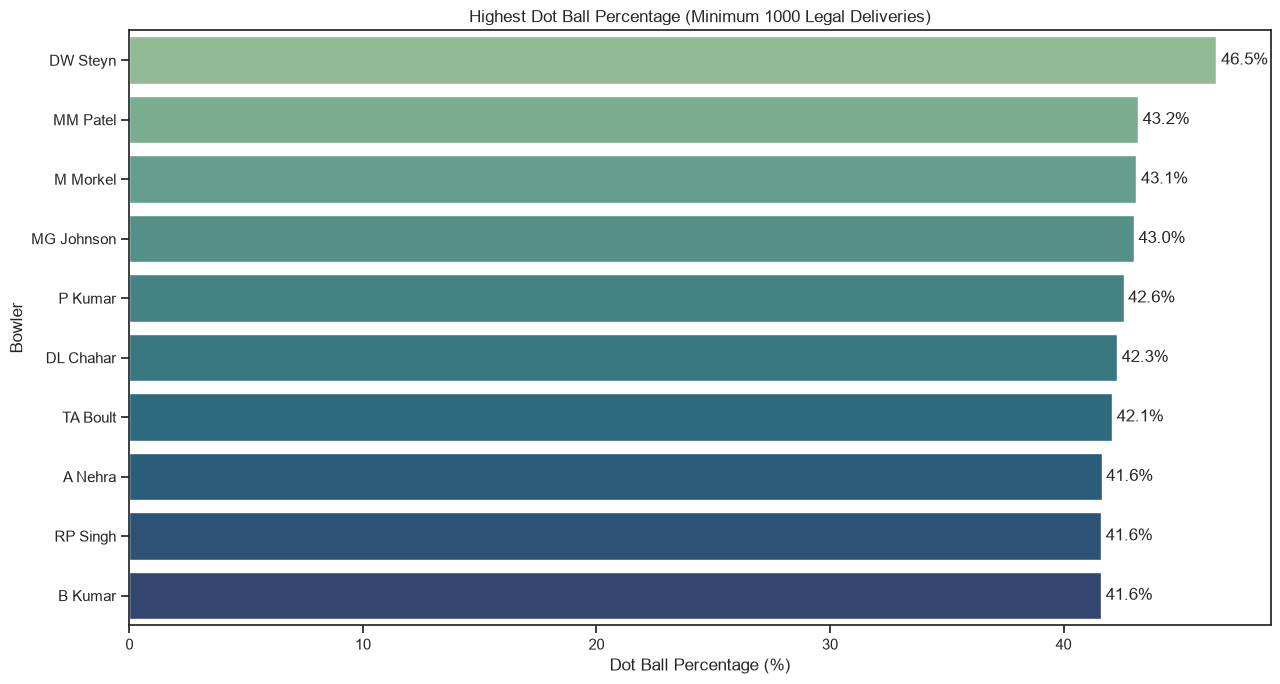

In [4]:
#Dot balls(legal deliveries with zero runs scored)
dot_balls = legal_deliveries[legal_deliveries["total_runs"] == 0]

#Dot ball count
dot_ball_count = dot_balls.groupby("bowler").size()

# Dot ball percentage
dot_ball_percentage = (dot_ball_count / balls_bowled * 100).round(2)

MIN_BALLS = 1000
qualified_dot_pct = (dot_ball_percentage[balls_bowled >= MIN_BALLS]
    .drop('R Sharma', errors='ignore').sort_values(ascending=False).head(10))
#display(qualified_dot_pct.to_frame(name='Dot Ball %'))

#Visualisation
plt.figure(figsize=(13,7))
sns.set_style("ticks")
sns.barplot(x=qualified_dot_pct.values,y=qualified_dot_pct.index,palette='crest', hue = qualified_dot_pct.index)

for i, value in enumerate(qualified_dot_pct.values):
    plt.text(
        value + 0.2,
        i,
        f'{value:.1f}%',
        va='center'
    )

plt.title('Highest Dot Ball Percentage (Minimum 1000 Legal Deliveries)')
plt.xlabel('Dot Ball Percentage (%)')
plt.ylabel('Bowler')

plt.tight_layout()
plt.savefig('charts/dot_ball_percentage.png', dpi=300)
plt.show()

### Observations

- **DW Steyn** has the highest dot-ball percentage at **46.5%**, meaning nearly half the balls he bowled were dot balls.
- Most bowlers with high dot-ball percentages also rank among the most economical, highlighting the strong relationship between pressure bowling and economy rate.
- Some bowlers generate pressure through dot balls even without being among the leading wicket-takers, demonstrating that restricting runs is valuable in its own right.